# Fake News Detection & Verification Platform

## WELFake Dataset — Dataset Analysis & Cleaning

### Project Objective

This notebook performs the initial data analysis and preparation of the WELFake
dataset for the Fake News Detection & Verification Platform.

The objectives are:

- Understand the dataset structure
- Analyze class distribution
- Identify missing values
- Identify duplicate records
- Analyze text and title characteristics
- Inspect label consistency
- Clean the dataset
- Prepare a reproducible dataset for NLP and machine learning

### Dataset

WELFake Dataset

The dataset contains news articles labeled as Real or Fake.

### Columns

- title
- text
- label

The original dataset also contains an index column, which will be removed
because it does not contain useful predictive information.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from collections import Counter

import re
import os

from sklearn.model_selection import train_test_split

In [ ]:

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [ ]:
df = pd.read_csv("WELFake_Dataset.csv", engine='python', on_bad_lines='skip', encoding='utf-8')

In [ ]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO],No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others o...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of North Carolina [VIDEO],"Now, most of the demonstrators gathered last night were exercising their constitutional and protected right to peaceful protest in order to raise issues and create change. Loretta Lynch aka Er...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid",A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in the context of presidential politics: how Louisiana Gov. Bobby Jindal traveled f...,0
4,4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per sec and with a range of 6,213 miles (10,000km) The weapons are perceived as part of an increasingly ag...",1


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (72154, 4)

Columns:
['Unnamed: 0', 'title', 'text', 'label']

Data Types:
Unnamed: 0    object
title         object
text          object
label         object
dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72154 entries, 0 to 72153
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72154 non-null  object
 1   title       71589 non-null  object
 2   text        72097 non-null  object
 3   label       72134 non-null  object
dtypes: object(4)
memory usage: 2.2+ MB


In [ ]:
df.describe(include="all")

,Unnamed: 0,title,text,label
count,72154,71589,72097,72134
unique,72154,62359,62720,4
top,72133,Factbox: Trump fills top jobs for his administration,,1
freq,1,14,738,37104


In [ ]:
df = df.drop(columns=["Unnamed: 0"])

In [ ]:
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO],No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others o...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of North Carolina [VIDEO],"Now, most of the demonstrators gathered last night were exercising their constitutional and protected right to peaceful protest in order to raise issues and create change. Loretta Lynch aka Er...",1
3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid",A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in the context of presidential politics: how Louisiana Gov. Bobby Jindal traveled f...,0
4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per sec and with a range of 6,213 miles (10,000km) The weapons are perceived as part of an increasingly ag...",1


In [ ]:
print(df.shape)
print(df.columns.tolist())

(72154, 3)
['title', 'text', 'label']


In [ ]:
df["label"].value_counts()

,count
label,
1,37104
0,35028
is just unbelievably rich from North Sea oil.,1
за участие. Благодарю вас.,1


In [ ]:
df["label"].unique()

array(['1', '0', None, ' is just unbelievably rich from North Sea oil. ',
       ' за участие. Благодарю вас.'], dtype=object)

In [ ]:
invalid_labels = [' is just unbelievably rich from North Sea oil. ', ' за участие. Благодарю вас.']
df = df[~df['label'].isin(invalid_labels)]

In [ ]:
# Convert 'label' column to numeric, coercing any remaining non-numeric values to NaN
df['label'] = pd.to_numeric(df['label'], errors='coerce')

# Drop rows where 'label' became NaN after conversion (these would be other unexpected non-numeric values)
df.dropna(subset=['label'], inplace=True)

# Convert 'label' to integer type
df['label'] = df['label'].astype(int)

Let's check the unique values and their counts in the `label` column after cleaning.

In [ ]:
print(df['label'].value_counts())
print(df['label'].unique())

label
1    37104
0    35028
Name: count, dtype: int64
[1 0]


In [ ]:
label_counts = df["label"].value_counts()

label_percentages = (
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(label_counts)
print("\nPercentage:")
print(label_percentages)

label
1    37104
0    35028
Name: count, dtype: int64

Percentage:
label
1    51.44
0    48.56
Name: proportion, dtype: float64


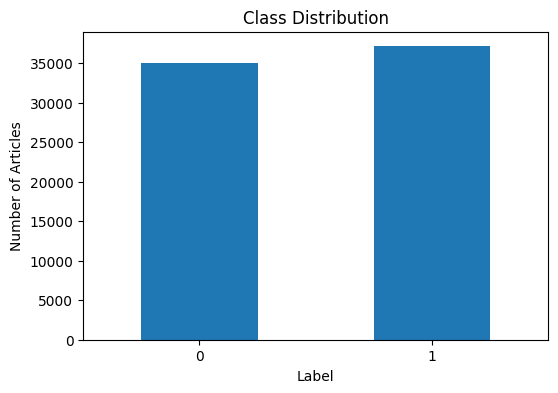

In [ ]:
plt.figure(figsize=(6, 4))

df["label"].value_counts().sort_index().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)

plt.show()

In [ ]:
for label in sorted(df["label"].unique()):
    print(f"\n========== LABEL {label} ==========\n")

    sample = df[df["label"] == label].sample(3, random_state=42)

    for _, row in sample.iterrows():
        print("TITLE:", row["title"])
        print("TEXT:", str(row["text"])[:500])
        print()


========== LABEL 0 ==========

TITLE: Two People Die after Eating Raw-Milk Cheese Made in New York State - The New York Times
TEXT: Two people have died following an outbreak of listeria linked to a popular artisanal raw milk cheese made in upstate New York, the authorities said this week. The deaths occurred in Vermont and Connecticut, local officials said. Four other people in New York and Florida reported feeling sick after eating Ouleout, the artisanal cheese, which is produced by Vulto Creamery in Walton. Illnesses started on dates from Sept. 1 of last year to Jan. 22, the Food and Drug Administration said. All six peop

TITLE: DUP blames Sinn Fein for Northern Ireland talks collapse
TEXT: BELFAST (Reuters) - A senior member of Northern Ireland s Democratic Unionist Party on Wednesday blamed rivals Sinn Fein for the collapse of talks on forming a power-sharing government and suggested the DUP would not compromise on the key issue of the Irish language.  In the first public statem

In [ ]:
label_mapping = {
    0: "Fake",
    1: "Real"
}

df["label_name"] = df["label"].map(label_mapping)

In [ ]:
df["label_name"].value_counts()

,count
label_name,
Real,37104
Fake,35028


In [ ]:
missing = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percentage
})

missing_report

,Missing Count,Missing Percentage
title,558,0.77
text,39,0.05
label,0,0.00
label_name,0,0.00


In [ ]:
print("Missing title:", df["title"].isna().sum())
print("Missing text:", df["text"].isna().sum())

Missing title: 558
Missing text: 39


In [ ]:
df[df["text"].isna()].head(10)

,title,text,label,label_name
2472,Après le succès de « Mariés au premier regard » M6 va lancer « Fécondées au premier regard » >> Le Gorafi,NaN,1,Real
3549,Elections US : les premières estimations donnent un candidat en avance sur l’autre >> Le Gorafi,NaN,1,Real
3724,110% des Américains assurent qu’ils continueront à faire confiance aux sondages >> Le Gorafi,NaN,1,Real
5627,Des millions d’Américains recherchent massivement « C’est quoi un Président des Etats-Unis » sur Google >> Le Gorafi,NaN,1,Real
6285,Vladimir Poutine est élu 45e Président des Etats-Unis >> Le Gorafi,NaN,1,Real
7017,Les Américains ne sont plus qu’à quelques heures d’être enfin tranquilles pour quatre ans >> Le Gorafi,NaN,1,Real
7103,Gorafi Magazine: Barack Obama « Je vous ai déjà dit que j’en avais plus rien à battre. Lâchez moi maintenant » >> Le Gorafi,NaN,1,Real
8994,Live Soirée présidentielle US 2016 >> Le Gorafi,NaN,1,Real
16737,"Ne supportant plus l’ambiance de la campagne électorale, un Français chanceux décide d’aller vivre dans l’espace >> Le Gorafi",NaN,1,Real
17801,Débat Primaire de la Droite : les Français pas à l’abri que des sujets de fonds soient accidentellement abordés >> Le Gorafi,NaN,1,Real


In [ ]:
df = df.dropna(subset=["text"])

In [ ]:
df["title"] = df["title"].fillna("")

In [ ]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 8456


In [ ]:
print("Duplicate texts:", df["text"].duplicated().sum())

Duplicate texts: 9377


In [ ]:
print("Duplicate titles:", df["title"].duplicated().sum())

Duplicate titles: 9786


In [ ]:
duplicate_texts = df[df["text"].duplicated(keep=False)]

duplicate_texts.sort_values("text").head(20)

,title,text,label,label_name
28753,Hillary Is 70 Days Away From Controlling All Food and Water,"\n\n \nIf Clinton is elected, Obama will hand her the power of a dictator.\nUpon Inauguration Day, Clinton will have the power to to the following:\n \nAs President, Hillary Clinton Would Have the...",1,Real
33521,Hillary Is 70 Days Away From Controlling All Food and Water,"\n\n \nIf Clinton is elected, Obama will hand her the power of a dictator.\nUpon Inauguration Day, Clinton will have the power to to the following:\n \nAs President, Hillary Clinton Would Have the...",1,Real
16439,Just Another Day In the Life of the Clinton Crime Family,"\n\n \nIn the past 24 hours, some very stunning pieces of information have leaked out regarding the Clinton Crime Family. I am shocked about how pervasive the criminality is in what has been only ...",1,Real
24653,Just Another Day In the Life of the Clinton Crime Family,"\n\n \nIn the past 24 hours, some very stunning pieces of information have leaked out regarding the Clinton Crime Family. I am shocked about how pervasive the criminality is in what has been only ...",1,Real
12690,"14 Days to Do 14 Things, If You Want to Survive the Fallout of Hillary’s New Indictment or Election Defeat","\n\n \nUPDATE: HILLARY CLINTON IS AGAIN UNDER INVESTIGATION BY THE FBI. IF SHE IS INDICTED, HER PEOPLE WILL UNDOUBTEDLY LAUNCH A CYBER ATTACK ON THE ELECTIONS AND BLAME THE RUSSIANS. HILLARY HAS T...",1,Real
1291,"14 Days to Do 14 Things, If Hillary’s Indicted-Extreme Violence Expected","\n\n \nUPDATE: HILLARY CLINTON IS AGAIN UNDER INVESTIGATION BY THE FBI. IF SHE IS INDICTED, HER PEOPLE WILL UNDOUBTEDLY LAUNCH A CYBER ATTACK ON THE ELECTIONS AND BLAME THE RUSSIANS. HILLARY HAS T...",1,Real
20024,"14 Days to Do 14 Things, If Hillary’s Indicted-Extreme Violence Expected","\n\n \nUPDATE: HILLARY CLINTON IS AGAIN UNDER INVESTIGATION BY THE FBI. IF SHE IS INDICTED, HER PEOPLE WILL UNDOUBTEDLY LAUNCH A CYBER ATTACK ON THE ELECTIONS AND BLAME THE RUSSIANS. HILLARY HAS T...",1,Real
24616,"CNN Fired Donna Brazile 2 Weeks Ago, Made It Public Now After Wikileaks Revelation",\n\nCNN finally made it public that they have severed ties with DNC chair Donna Brazile after a new Wikileaks email revealed more CNN collusion with Clinton campaign after Donna Brazile gave Hilla...,1,Real
28363,"CNN Fired Donna Brazile 2 Weeks Ago, Made It Public Now After Wikileaks Revelation",\n\nCNN finally made it public that they have severed ties with DNC chair Donna Brazile after a new Wikileaks email revealed more CNN collusion with Clinton campaign after Donna Brazile gave Hilla...,1,Real
23456,"Project Veritas Video 4 - 20K Bribery to DNC, Chaos at Trump Rallies","\n\nIn the effort to prove the credibility of the undercover donor featured in the videos and to keep the investigation going, Project Veritas Action made the decision to donate twenty thousand do...",1,Real


In [ ]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 72093
Rows after: 63637
Duplicates removed: 8456


In [ ]:
df["title_length"] = df["title"].str.len()

df["text_length"] = df["text"].str.len()

df["title_words"] = df["title"].str.split().str.len()

df["text_words"] = df["text"].str.split().str.len()

In [ ]:
df[[
    "title_length",
    "text_length",
    "title_words",
    "text_words"
]].describe()

,title_length,text_length,title_words,text_words
count,63637.000000,63637.000000,63637.000000,63637.000000
mean,74.554913,3274.508572,11.889435,541.954115
std,23.612399,3556.457931,3.972527,597.783474
min,0.000000,1.000000,0.000000,0.000000
25%,61.000000,1431.000000,9.000000,235.000000
50%,72.000000,2457.000000,11.000000,403.000000
75%,86.000000,4097.000000,14.000000,674.000000
max,456.000000,115372.000000,72.000000,20891.000000


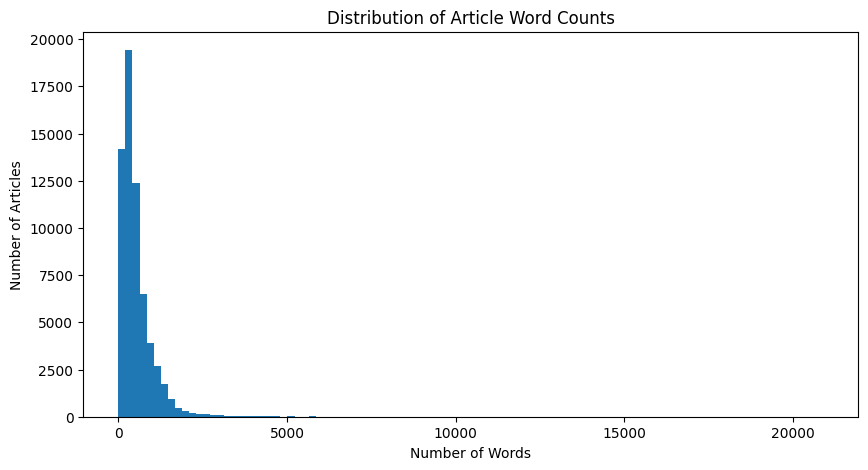

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["text_words"],
    bins=100
)

plt.title("Distribution of Article Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")

plt.show()

In [ ]:
df.groupby("label_name")[["title_words", "text_words"]].mean()

,title_words,text_words
label_name,,
Fake,11.052284,578.252278
Real,12.899119,498.175102


In [ ]:
df.groupby("label_name")[["title_words", "text_words"]].median()

,title_words,text_words
label_name,,
Fake,11.0,427.0
Real,13.0,374.0


In [ ]:
print(
    "Articles with 0 words:",
    (df["text_words"] == 0).sum()
)

Articles with 0 words: 529


In [ ]:
df[df["text_words"] < 10][
    ["title", "text", "label_name"]
].head(20)

,title,text,label_name
1,,Did they post their votes for Hillary already?,Real
7,HOUSE INTEL CHAIR On Trump-Russia Fake Story: “No evidence of anything” [Video],,Real
79,‘Arab Spring’ and the Washington-Brussels-Riyadh Axis,Be the First to Comment! Search articles,Real
106,MARKETWATCH LEFTIST: MSM’s “Blatant” Anti Trump Bias May Be Suicidal,,Real
185,,Cool,Real
244,WORLD WAR 3 IS COMING,source Add To The Conversation Using Facebook Comments,Real
325,Ohio State University Student Says Terrorist Attack Was “Misunderstanding” Caused By Racism [VIDEO],,Real
373,,Obamas blunder.,Real
379,JULIAN ASSANGE REVEALS John Podesta’s Hilarious Email Password…”A 14 Year Old Kid Could’ve Hacked Podesta” [VIDEO],,Real
436,HEATED! TUCKER CARLSON Totally Shuts Down Radical Liberal FOX News Analyst Who’s Running For DNC Chair [Video],https://www.youtube.com/watch?v=RRPSCqkAJgk,Real


In [ ]:
def basic_clean_text(text):
    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    # Strip leading/trailing whitespace
    text = text.strip()

    return text

In [ ]:
df["clean_text"] = df["text"].apply(basic_clean_text)
df["clean_title"] = df["title"].apply(basic_clean_text)

In [ ]:
final_df = df[
    [
        "clean_title",
        "clean_text",
        "label"
    ]
].copy()

In [ ]:
final_df = final_df.rename(columns={
    "clean_title": "title",
    "clean_text": "text"
})

In [ ]:
final_df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO],No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others o...,1
1,,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of North Carolina [VIDEO],"Now, most of the demonstrators gathered last night were exercising their constitutional and protected right to peaceful protest in order to raise issues and create change. Loretta Lynch aka Eric H...",1
3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid",A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in the context of presidential politics: how Louisiana Gov. Bobby Jindal traveled f...,0
4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per sec and with a range of 6,213 miles (10,000km) The weapons are perceived as part of an increasingly ag...",1


In [ ]:
print("Final Shape:", final_df.shape)

print("\nMissing Values:")
print(final_df.isnull().sum())

print("\nDuplicate Rows:")
print(final_df.duplicated().sum())

print("\nClass Distribution:")
print(final_df["label"].value_counts())

Final Shape: (63637, 3)

Missing Values:
title    0
text     0
label    0
dtype: int64

Duplicate Rows:
9

Class Distribution:
label
0    34791
1    28846
Name: count, dtype: int64


In [ ]:
final_df = final_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [ ]:
X = final_df["text"]
y = final_df["label"]

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

Training: 50909
Validation: 6364
Testing: 6364


In [ ]:
print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_val.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))


Train:
label
0    0.546701
1    0.453299
Name: proportion, dtype: float64

Validation:
label
0    0.546669
1    0.453331
Name: proportion, dtype: float64

Test:
label
0    0.546826
1    0.453174
Name: proportion, dtype: float64


In [ ]:
final_df.to_csv(
    "WELFake_Cleaned.csv",
    index=False
)

In [ ]:
import csv
final_df.to_csv(
    "WELFake_Cleaned.csv",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL,
    lineterminator="\n"
)

In [ ]:
test_df = pd.read_csv(
    "WELFake_Cleaned.csv",
    engine="python"
)

print(test_df.shape)
print(test_df.columns)
print(test_df.isnull().sum())

(63637, 3)
Index(['title', 'text', 'label'], dtype='object')
title    524
text     582
label      0
dtype: int64
